In [2]:
# Common imports
import matplotlib.pyplot as plt
import xarray as xr
import scipy.constants as const
from scipy.linalg import eigh
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import numpy as np

import seaborn as sns

## Constants and calibrational data

In [3]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J


# ------------------ System parameters ------------------
T = 15e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2

## Data loading and preprocessing

In [4]:
# # Preprocess 2D dataset for the bottom row
dataset_2d = xr.load_dataset("Data/Resonator_2d_map.hdf5")

# dataset_2d = dataset_raw.copy(deep=True)

a= (1.7795-1.7765)/(0.690-0.725)
b= 1.7730-a*0.725

offset = a * dataset_2d.x1 + b

dataset_2d = dataset_2d.assign_coords(
    x1 = dataset_2d.x1 * 1.1126 - 0.4,
    x2 = dataset_2d.x2 * 1.0753 + offset,
    x0 = dataset_2d.x0 * 1e-9
)

In [5]:
# Define datasets with unique keys
datasets = {
    "bl_zoom_ds1_tt": "Data/Q2_DS_1/DS_1_Resonator_spec.hdf5",
    "bl_zoom_ds2_tt": "Data/Q2_DS_2/DS_2_Resonator_spec.hdf5",
    "bl_zoom_ds3_tt": "Data/Q2_DS_3/DS_3_Resonator_spec.hdf5",
    "bl_zoom_ds4_tt": "Data/Q2_DS_4/DS_4_Resonator_spec.hdf5",
}

# Optional: define custom dimensions for each dataset (if different)
dataset_dims = {
    "bl_zoom_ds1_tt":  (301, 250),
    "bl_zoom_ds2_tt": (301, 150),
    "bl_zoom_ds3_tt": (301, 150),
    "bl_zoom_ds4_tt": (301, 151),
}


adjustments = {
    "bl_zoom_ds1_tt": {"x_scale": 1.0753, "x_shift": 1.773, "y_scale": 1e-9, "z_shift": 0},
    "bl_zoom_ds2_tt": {"x_scale": 1.0753, "x_shift": 1.77631 ,"y_scale": 1e-9, "z_shift": 0},
    "bl_zoom_ds3_tt": {"x_scale": 1.0753, "x_shift": 1.778, "y_scale": 1e-9, "z_shift": 0},
    "bl_zoom_ds4_tt": {"x_scale": 1.0753, "x_shift": 1.778, "y_scale": 1e-9, "z_shift": 0},
}

## Hamiltonian construction

In [6]:
def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:


    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------
    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, D1, phis

In [7]:
Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm


a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

## Resonator dispersive shift computation

In [8]:
def compute_resonator_shift(
    H_all, D1,
    flux1,
    f_r, g,
    n_levels=15
):

    eigvals_all = np.zeros((len(flux1), n_levels))
    matrix_chi1 = np.zeros(len(flux1))
    matrix_chi2 = np.zeros(len(flux1))

    for f_i, H in enumerate(H_all):
        vals, vecs = eigh(H)
        vals = np.real(vals[:n_levels])
        eigvals_all[f_i, :] = vals

        n_op = -1j * D1  # n = -i ∂/∂phi
        n0 = np.array([np.vdot(vecs[:, i], n_op.dot(vecs[:, 0])) for i in range(n_levels)])
        n1 = np.array([np.vdot(vecs[:, i], n_op.dot(vecs[:, 1])) for i in range(n_levels)])


        w = 2 * np.pi * vals
        wr = 2 * np.pi * f_r
        gc = 2 * np.pi * g

        domega = 0
        for i in range(1, n_levels):
            w_i0 = w[i] - w[0]
            num = abs(n0[i])**2
            denom = (w_i0**2 - wr**2)
            domega += num * (-2 * w_i0 / denom)

        domega1 = 0
        for i in range(1, n_levels):
            w_i1 = w[i] - w[1]
            num = abs(n1[i])**2
            denom = (w_i1**2 - wr**2)
            domega1 += num * (-2 * w_i1 / denom)


    
        matrix_chi1[f_i] = (gc**2 * domega) / (2 * np.pi)
        matrix_chi2[f_i] = (gc**2 * domega1) / (2 * np.pi)  
        # + (gc**2 * domega1) / (2 * np.pi) 

    # --- Resonator frequency shift ---
    fr_disp1 = f_r + matrix_chi1
    fr_disp2 = f_r + matrix_chi2


    return fr_disp1, fr_disp2, matrix_chi1, eigvals_all

In [9]:
def compute_theory_for_panel(EJ1,EJ2,EJ3,EJ4,EJ5,Ec,phi,phi_ext,flux2):
    """Compute theory curves individually for each panel."""
    H_all, D1, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        phis=phi,
        flux1=phi_ext,
        flux2=flux2,
        Ec=Ec, ng=0,
    )

    fr1, fr2, chi, eigvals = compute_resonator_shift(
        H_all, D1, phi_ext, f_r, g
    )
    return fr1, fr2



## Plotting functions

In [10]:
# ------------------ Plotting utilities ------------------
def plot_one_resonator_panel(
        ax, dataset_key, flux2,
        phi_ext, fr1, fr2,
        adjustments, dataset_dims, datasets,
        cmap="Oranges_r"
    ):

    # Load dataset
    dataset = xr.load_dataset(datasets[dataset_key])
    xlen, ylen = dataset_dims[dataset_key]

    x0 = dataset["x0"].data
    x1 = dataset["x1"].values
    y0 = dataset["y0"].values

    X = x0.reshape(ylen, xlen)
    Y = x1.reshape(ylen, xlen)
    Z = y0.reshape(ylen, xlen)

    # Apply adjustments
    adj = adjustments[dataset_key]
    x_scale = adj["x_scale"]
    x_shift = adj["x_shift"]
    y_scale = adj["y_scale"]
    z_shift = adj["z_shift"]

    Z = Z - z_shift

    # Scaled axes
    X_plot = X[0] * y_scale
    Y_plot = Y[:, 0] * x_scale + x_shift

    # Experimental data
    hm = ax.pcolormesh(Y_plot, X_plot, Z.T, shading='auto', cmap=cmap, rasterized=True)

    # Theory curve for this flux2
    line1 = ax.plot(phi_ext, fr1, lw=1.5, color='tab:blue')
    line2 = ax.plot(phi_ext, fr2, lw=1.5, color='tab:green')

    # Axis range
    ax.set_xlim(Y_plot.min(), Y_plot.max())
    ax.set_ylim(X_plot.min(), X_plot.max())

    return hm, line1, line2

In [11]:
def compute_relative_ticks(vmin, vmax, n=5):
    """Return ticks at equal relative spacing between min and max."""
    return np.linspace(vmin, vmax, n)


def compute_centered_ticks(xmin, xmax, center=0.5, n_each_side=2):
    # distance allowed to stay inside dataset
    step = min(center - xmin, xmax - center) / n_each_side
    return [center + i * step for i in range(-n_each_side, n_each_side + 1)]

## System parameters

In [12]:
phi = np.linspace(0, 1, 101)

flux1_vals = np.linspace(0.3, 0.7, 51)  # Flux1
flux2_vals = np.linspace(0.2, 0.8, 51)  # Flux2
phi_ext = np.linspace(0.4, 0.6, 201) # Flux1 for line cut simulation 

n_levels = 15

Ec = 0.21
EJ1 = 42.49
EJ2 = 53.930
EJ3  = 88.11
EJ4  = 35.73
EJ5  = 35.73
ng = 0.0

f_r = 5.2344 # GHz
g = 0.025 # GHz

phi_2_datasets = {
    "bl_zoom_ds1_tt": {"phi_2": 0.406},
    "bl_zoom_ds2_tt": {"phi_2": 0.395},
    "bl_zoom_ds3_tt": {"phi_2": 0.378},
    "bl_zoom_ds4_tt": {"phi_2": 0.367},
}
dataset_keys = ["bl_zoom_ds1_tt", "bl_zoom_ds2_tt", "bl_zoom_ds3_tt", "bl_zoom_ds4_tt"]

## Main computation


In [13]:

# Prepare 2D array to hold minimum dispersive shift
chi_min_2d = np.zeros((len(flux1_vals), len(flux2_vals)))

# ----------------------------
# Loop over 2D flux grid
for i, flux1 in enumerate(flux1_vals):
    for j, flux2 in enumerate(flux2_vals):
        # Build Hamiltonian for this flux point
        H_all, D1, _ = build_phase_hamiltonians(
            EJ1, EJ2, EJ3, EJ4, EJ5,
            np.array([flux1]), flux2, phi, Ec, ng
        )
        # Compute dispersive shift
        fr_disp1, fr_disp2, matrix_chi, eigvals_all = compute_resonator_shift(
            H_all, D1, np.array([flux1]), f_r, g, n_levels
        )
        # Take minimum shift (argmin along levels)
        chi_min_2d[i, j] = np.min(matrix_chi)


results = {}
for key in dataset_keys:
    flux2 = phi_2_datasets[key]["phi_2"]
    fr1, fr2 = compute_theory_for_panel(EJ1, EJ2, EJ3, EJ4, EJ5, Ec, phi, phi_ext, flux2)
    results[key] = {
        "flux2": flux2,
        "fr1": fr1,
        "fr2": fr2
    }

heatmap = dataset_2d.x0[dataset_2d.y0.fillna(0).argmin('x0')][::2]
heatmap = heatmap.assign_coords(
    x0=heatmap.x0 - f_r
)

## Visualization

In [14]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

my_cmap =sns.cubehelix_palette(start=.5, rot=-.85, as_cmap=True)
blue_cmap = my_cmap
blue_colors1 = blue_cmap(np.linspace(0.5, 0.9, 4))

markers = ['^','D', 's', 'o', ]  # triangle, circle, square, plus

hline_freqs = [phi_2_datasets[k]["phi_2"] for k in dataset_keys]
hline_colors = blue_colors1

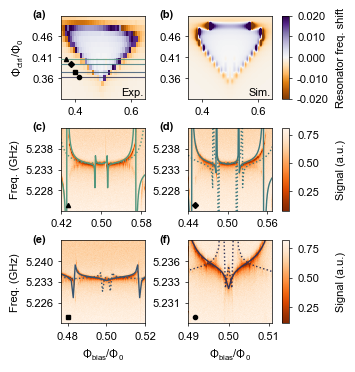

In [17]:

fig = plt.figure() 
fig.set_size_inches(3.40457, 3.6)

fig.subplots_adjust(top=0.965, bottom=0.11, left=0.16, right=0.83)
gs = gridspec.GridSpec(
    3, 5,  # 3 rows, 5 columns (2 gaps + 1 colorbar)
    width_ratios=[1, 0.25, 1, -0.15, 0.09],   # adjust gap sizes here
    height_ratios=[1, 1, 1], 
    hspace=0.35, 
    wspace=0.3, 
)

# # --- Last row 2D maps ---
ax_e = fig.add_subplot(gs[0, 2])
ax_f = fig.add_subplot(gs[0, 0])
cax_bottom2 = fig.add_subplot(gs[0, 4])

# Left 2D map (e)
im = ax_e.imshow(
    chi_min_2d.T,
    origin="lower",
    extent=[flux1_vals.min(), flux1_vals.max(),
            flux2_vals.min(), flux2_vals.max()],
    aspect="auto",
    cmap="PuOr",
    vmin=-0.02, vmax=0.02
)
# ax_e.set_xlabel(r"$\Phi_{ext_1}/\Phi_0$")


# Right 2D map (f)
heatmap.plot(ax=ax_f, rasterized=True, add_colorbar=False, add_labels=False, cmap="PuOr")
ax_f.set_aspect('auto') 

ax_f.set_ylabel(r"$\Phi_{\mathrm{ctrl}}/\Phi_0$")
ax_f.set_yticklabels([])
ax_e.set_ylim(0.32, 0.5)
ax_e.set_xlim(0.35, 0.65)
ax_f.set_ylim(0.32, 0.5)
ax_f.set_xlim(0.35, 0.65)

# Adjust ticks for bottom row
for ax in [ax_e, ax_f]:
    ymin, ymax = ax.get_ylim()
    yticks = np.linspace(ymin, ymax, 5)[1:-1]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:.2f}" for t in yticks])


x_start = ax_f.get_xlim()[0]

for f, c, m in zip(hline_freqs, hline_colors, markers):
    ax_f.axhline(
        f,
        color=c,
        linestyle='-',
        linewidth=0.8,
        alpha=0.8,
        zorder=10
    )

    # marker at the beginning of the line
for i, (f, m) in enumerate(zip(hline_freqs, markers)):
    ax_f.plot(
        x_start + 0.018+i * 0.015,  
        f,
        marker=m,
        color='black',
        markersize=3,
        linestyle='None',
        zorder=11,
        clip_on=False
    )

# Shared colorbar for bottom row
cbar3 = plt.colorbar(im, cax=cax_bottom2)
cbar3.set_label("Resonator freq. shift")
cbar3.ax.yaxis.set_label_coords(10, 0.5)
cbar3_ticks = np.linspace(im.get_clim()[0], im.get_clim()[1], 5)
cbar3.set_ticks(cbar3_ticks)
cbar3.set_ticklabels([f"{t:.3f}" for t in cbar3_ticks])

ax_f.text(
    0.98, 0.02, "Exp.",
    transform=ax_f.transAxes,
    ha="right", va="bottom",
)

ax_e.text(
    0.98, 0.02, "Sim.",
    transform=ax_e.transAxes,
    ha="right", va="bottom",
)
# ------------------- GRID SETUP ---------------------------


ax11 = fig.add_subplot(gs[1, 0])
ax12 = fig.add_subplot(gs[1, 2])
cax_top = fig.add_subplot(gs[1, 4])

ax21 = fig.add_subplot(gs[2, 0])
ax22 = fig.add_subplot(gs[2, 2])
cax_bottom = fig.add_subplot(gs[2, 4])


axes = [ax11, ax12, ax21, ax22]

mappable_top = None
mappable_bottom = None

for idx, (ax, key) in enumerate(zip(axes, dataset_keys)):
    data = results[key]
    hm, line1, line2= plot_one_resonator_panel(ax, key, data["flux2"], phi_ext, data["fr1"], data["fr2"],
                                  adjustments, dataset_dims, datasets)
    
    line1 = ax.lines[-2]  # fr1
    line2 = ax.lines[-1]  # fr2
    line1.set_color(blue_colors1[idx])
    line1.set_linewidth(1)   # thickness
    line1.set_alpha(1)       # transparency (0=fully transparent, 1=opaque)

    line2.set_color(blue_colors1[idx])
    line2.set_linewidth(1.0)
    line2.set_linestyle(':')
    line2.set_alpha(1)
    
    if idx < 2 and mappable_top is None:
        mappable_top = hm
    if idx >= 2 and mappable_bottom is None:
        mappable_bottom = hm

    # Ticks formatting
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xticks = compute_centered_ticks(xmin, xmax, center=0.5, n_each_side=1)
    yticks = np.linspace(ymin, ymax, 5)[1:-1]
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{t:.2f}" for t in xticks])
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{t:.3f}" for t in yticks])
    ax.tick_params(axis='both', which='major', length=2, width=0.5)

    ax.plot(
    0.08, 0.08,                       # position in axes coordinates
    marker=markers[idx],
    color='black',
    markersize=3,
    linestyle='None',
    transform=ax.transAxes,
    clip_on=False,
    zorder=10
)

# Labels
ax11.set_ylabel("Freq. (GHz)")
ax21.set_ylabel("Freq. (GHz)")

ax21.set_xlabel(r"$\Phi_{\mathrm{bias}}/\Phi_0$")
ax22.set_xlabel(r"$\Phi_{\mathrm{bias}}/\Phi_0$")
for cax in [cax_top, cax_bottom, cax_bottom2]:
    cax.yaxis.set_label_coords(7.1, 0.5)

# Colorbars
plt.colorbar(mappable_top, cax=cax_top, label="Signal (a.u.)")
plt.colorbar(mappable_bottom, cax=cax_bottom, label="Signal (a.u.)")

# --- Panel letters ---
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, label in zip([ ax_f, ax_e, ax11, ax12, ax21, ax22], panel_labels):
    ax.text(-0.35, 1.075, label, transform=ax.transAxes,
            fontweight='bold', ha='left', va='top')
    
fig.savefig("Fig2_Resonator.pdf", dpi=600)

plt.show()
